# EDA -- MNIST и Fashion-MNIST

> Сорочан Дмитрий, [@legenda0008](https://t.me/legenda0008)


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from sklearn.model_selection import train_test_split
from torchvision.datasets import FashionMNIST, MNIST


SEED = 143
CACHE_DIR = Path.home() / ".cache" / "mlstart_hw03"
REPORT_DIR = Path("report")
FIGURES_DIR = REPORT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(SEED)
sns.set_theme(style="whitegrid")


In [2]:
mnist = MNIST(CACHE_DIR, train=True, download=True)
fashion = FashionMNIST(CACHE_DIR, train=True, download=True)

mnist_images = mnist.data.numpy()
mnist_targets = mnist.targets.numpy()

fashion_images = fashion.data.numpy()
fashion_targets = fashion.targets.numpy()

FASHION_LABELS = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]


100%|██████████| 9.91M/9.91M [00:01<00:00, 7.99MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 360kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 17.9MB/s]
100%|██████████| 26.4M/26.4M [00:02<00:00, 10.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 506kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 7.93MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 31.8MB/s]


## Общая информация

Оба датасета имеют одинаковый технический формат: 60 000 grayscale-изображений `28 × 28`, 10 классов, пиксели `uint8` в диапазоне `[0, 255]`.


In [3]:
dataset_info = pd.DataFrame([
    {
        "dataset": "MNIST",
        "objects": len(mnist_images),
        "height": mnist_images.shape[1],
        "width": mnist_images.shape[2],
        "classes": np.unique(mnist_targets).size,
        "dtype": str(mnist_images.dtype),
        "min_pixel": mnist_images.min(),
        "max_pixel": mnist_images.max(),
    },
    {
        "dataset": "Fashion-MNIST",
        "objects": len(fashion_images),
        "height": fashion_images.shape[1],
        "width": fashion_images.shape[2],
        "classes": np.unique(fashion_targets).size,
        "dtype": str(fashion_images.dtype),
        "min_pixel": fashion_images.min(),
        "max_pixel": fashion_images.max(),
    },
])

dataset_info


,dataset,objects,height,width,classes,dtype,min_pixel,max_pixel
0,MNIST,60000,28,28,10,uint8,0,255
1,Fashion-MNIST,60000,28,28,10,uint8,0,255


In [4]:
pd.DataFrame({
    "dataset": ["MNIST", "Fashion-MNIST"],
    "nan_pixels": [
        np.isnan(mnist_images.astype(np.float32)).sum(),
        np.isnan(fashion_images.astype(np.float32)).sum(),
    ],
    "nan_targets": [
        np.isnan(mnist_targets.astype(np.float32)).sum(),
        np.isnan(fashion_targets.astype(np.float32)).sum(),
    ],
})


,dataset,nan_pixels,nan_targets
0,MNIST,0,0
1,Fashion-MNIST,0,0


Пропусков нет.  
Для изображений нет категориальных признаков и отдельного feature engineering в табличном смысле.


## Баланс классов


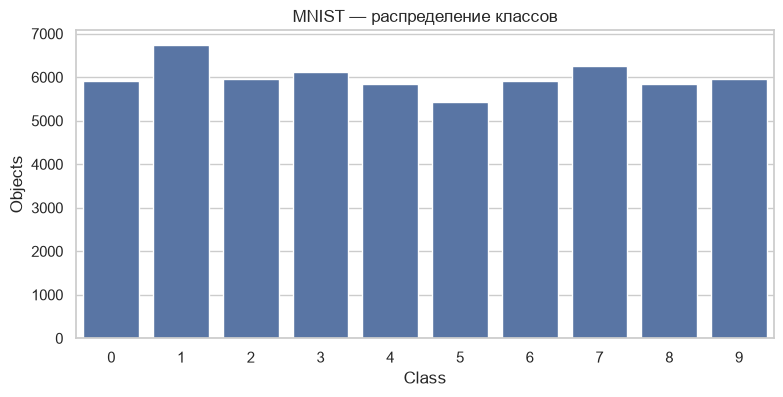

In [5]:
mnist_counts = pd.Series(mnist_targets).value_counts().sort_index()

plt.figure(figsize=(9, 4))
sns.barplot(x=mnist_counts.index, y=mnist_counts.values)
plt.title("MNIST — распределение классов")
plt.xlabel("Class")
plt.ylabel("Objects")
plt.savefig(FIGURES_DIR / "eda_mnist_class_balance.png", bbox_inches="tight")
plt.show()


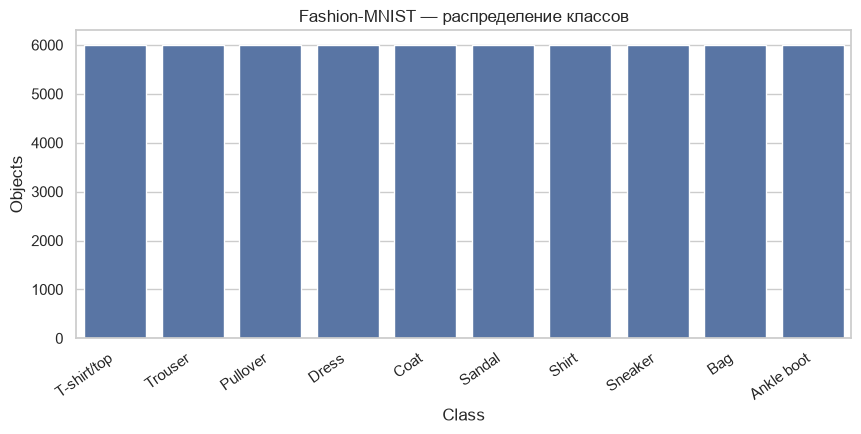

In [6]:
fashion_counts = pd.Series(fashion_targets).value_counts().sort_index()

plt.figure(figsize=(10, 4))
sns.barplot(x=FASHION_LABELS, y=fashion_counts.values)
plt.title("Fashion-MNIST — распределение классов")
plt.xlabel("Class")
plt.ylabel("Objects")
plt.xticks(rotation=35, ha="right")
plt.savefig(FIGURES_DIR / "eda_fashion_class_balance.png", bbox_inches="tight")
plt.show()


Оба датасета почти сбалансированы _(`fashion` прям идеально )_. 

Основной метрикой можно взять `accuracy`, а `macro-F1` использую как дополнительную: она позволяет проверить, не маскирует ли accuracy провал на отдельных классах.


## Случайные объекты


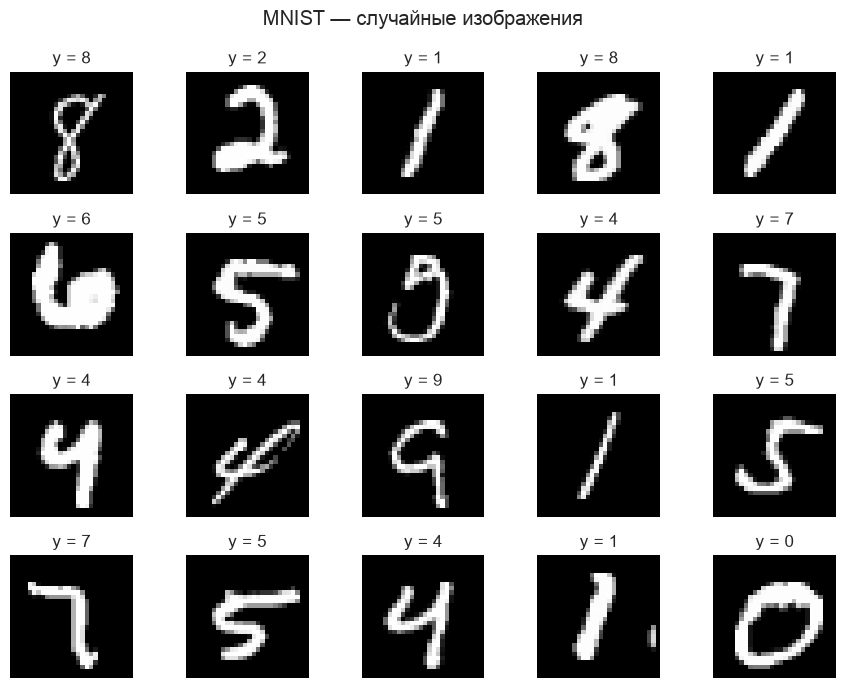

In [7]:
indices = rng.choice(len(mnist_images), size=20, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(9, 7))
for ax, index in zip(axes.ravel(), indices):
    ax.imshow(mnist_images[index], cmap="gray")
    ax.set_title(f"y = {mnist_targets[index]}")
    ax.axis("off")

fig.suptitle("MNIST — случайные изображения")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_mnist_examples.png", bbox_inches="tight")
plt.show()


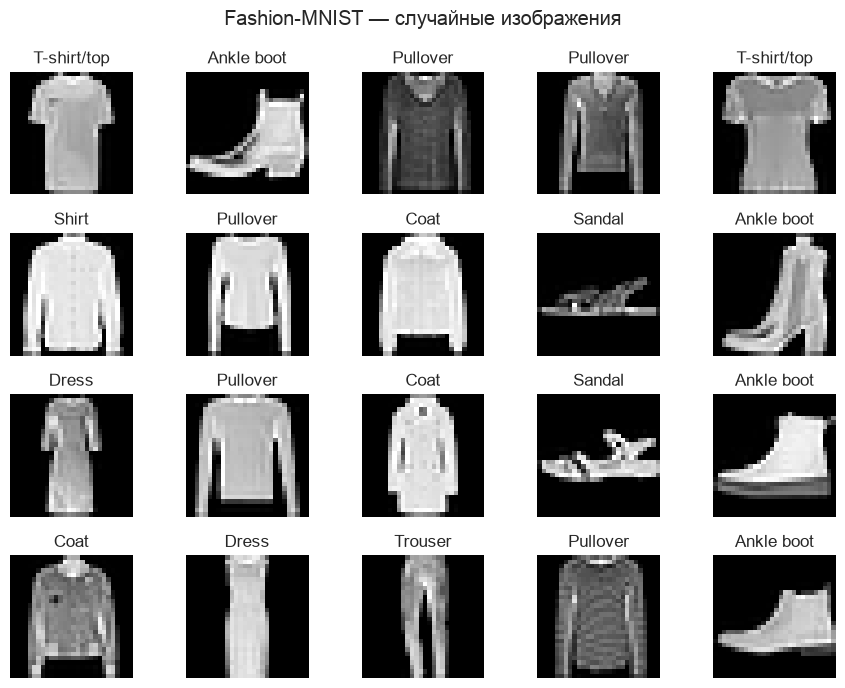

In [8]:
indices = rng.choice(len(fashion_images), size=20, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(9, 7))
for ax, index in zip(axes.ravel(), indices):
    ax.imshow(fashion_images[index], cmap="gray")
    ax.set_title(FASHION_LABELS[fashion_targets[index]])
    ax.axis("off")

fig.suptitle("Fashion-MNIST — случайные изображения")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_fashion_examples.png", bbox_inches="tight")
plt.show()


`MNIST` визуально проще: классы задаются формой цифры на почти пустом фоне.

В `Fashion-MNIST` несколько классов похожи друг на друга (`T-shirt/top`, `Shirt`, `Pullover`, `Coat`), поэтому ожидаю более низкое качество при той же архитектуре.


## Средний объект каждого класса


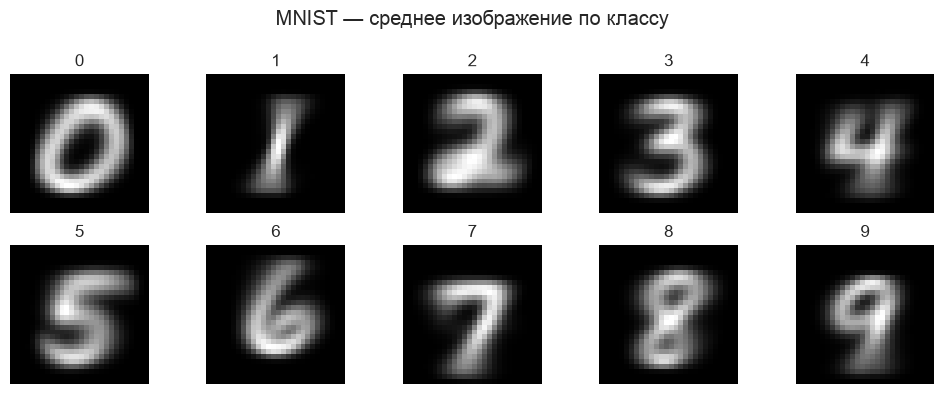

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for label, ax in enumerate(axes.ravel()):
    mean_image = mnist_images[mnist_targets == label].mean(axis=0)
    ax.imshow(mean_image, cmap="gray")
    ax.set_title(str(label))
    ax.axis("off")

fig.suptitle("MNIST — среднее изображение по классу")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_mnist_class_means.png", bbox_inches="tight")
plt.show()


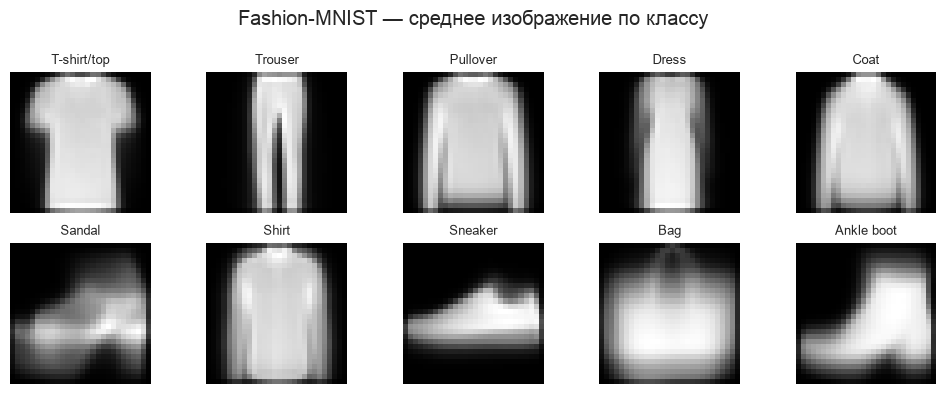

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for label, ax in enumerate(axes.ravel()):
    mean_image = fashion_images[fashion_targets == label].mean(axis=0)
    ax.imshow(mean_image, cmap="gray")
    ax.set_title(FASHION_LABELS[label], fontsize=9)
    ax.axis("off")

fig.suptitle("Fashion-MNIST — среднее изображение по классу")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_fashion_class_means.png", bbox_inches="tight")
plt.show()


## Распределение интенсивности пикселей


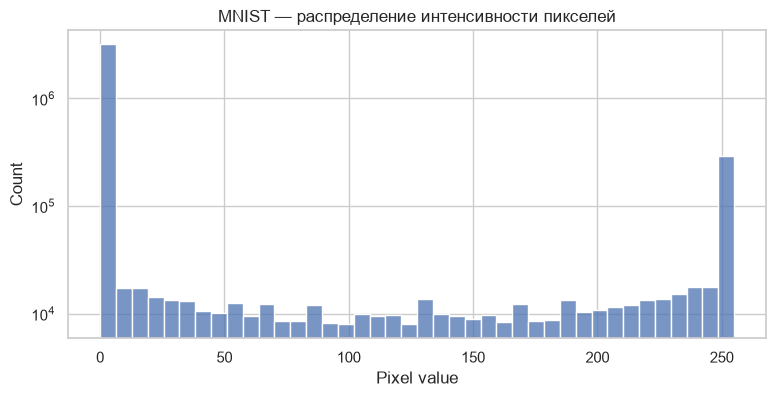

In [11]:
sample_pixels = mnist_images[rng.choice(len(mnist_images), size=5000, replace=False)].ravel()

plt.figure(figsize=(9, 4))
sns.histplot(sample_pixels, bins=40)
plt.title("MNIST — распределение интенсивности пикселей")
plt.xlabel("Pixel value")
plt.ylabel("Count")
plt.yscale("log")
plt.savefig(FIGURES_DIR / "eda_mnist_pixel_hist.png", bbox_inches="tight")
plt.show()


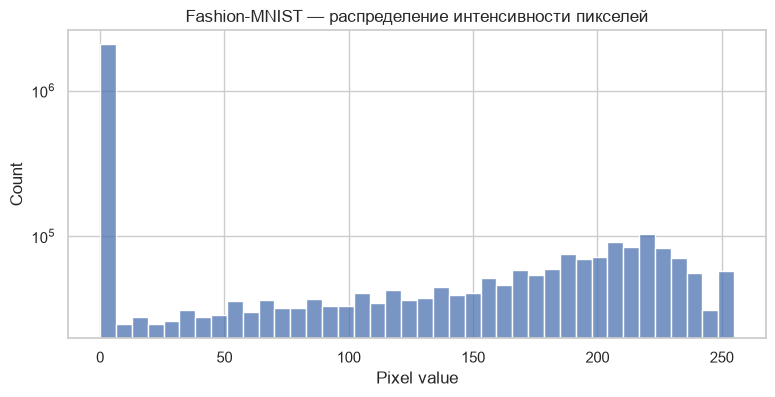

In [12]:
sample_pixels = fashion_images[rng.choice(len(fashion_images), size=5000, replace=False)].ravel()

plt.figure(figsize=(9, 4))
sns.histplot(sample_pixels, bins=40)
plt.title("Fashion-MNIST — распределение интенсивности пикселей")
plt.xlabel("Pixel value")
plt.ylabel("Count")
plt.yscale("log")
plt.savefig(FIGURES_DIR / "eda_fashion_pixel_hist.png", bbox_inches="tight")
plt.show()


У `MNIST` существенно больше фоновых нулей.  
`Fashion-MNIST` заполняет изображение плотнее, поэтому средняя яркость и дисперсия пикселей выше. Нормализация особенно полезна для стабильной оптимизации MLP.


## Яркость изображения


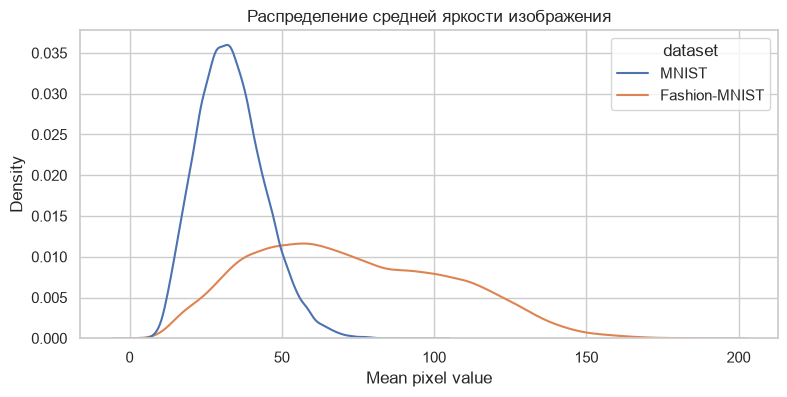

In [13]:
mnist_brightness = mnist_images.mean(axis=(1, 2))
fashion_brightness = fashion_images.mean(axis=(1, 2))

brightness_df = pd.DataFrame({
    "brightness": np.r_[mnist_brightness, fashion_brightness],
    "dataset": ["MNIST"] * len(mnist_brightness) + ["Fashion-MNIST"] * len(fashion_brightness),
})

plt.figure(figsize=(9, 4))
sns.kdeplot(data=brightness_df, x="brightness", hue="dataset", common_norm=False)
plt.title("Распределение средней яркости изображения")
plt.xlabel("Mean pixel value")
plt.savefig(FIGURES_DIR / "eda_brightness_distribution.png", bbox_inches="tight")
plt.show()


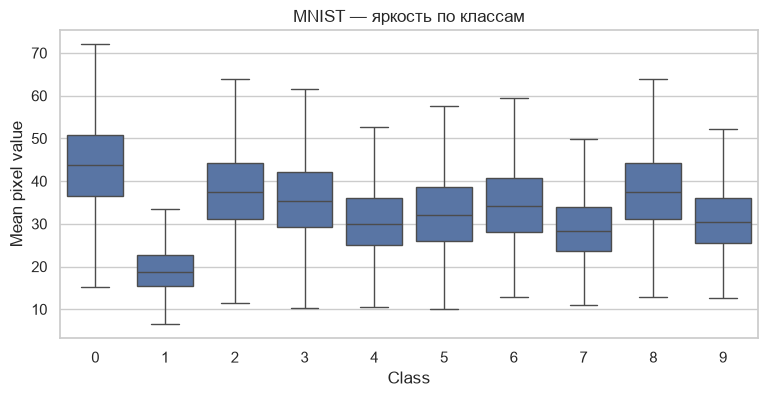

In [14]:
mnist_class_brightness = pd.DataFrame({
    "class": mnist_targets,
    "brightness": mnist_brightness,
})

plt.figure(figsize=(9, 4))
sns.boxplot(data=mnist_class_brightness, x="class", y="brightness", showfliers=False)
plt.title("MNIST — яркость по классам")
plt.xlabel("Class")
plt.ylabel("Mean pixel value")
plt.savefig(FIGURES_DIR / "eda_mnist_brightness_by_class.png", bbox_inches="tight")
plt.show()


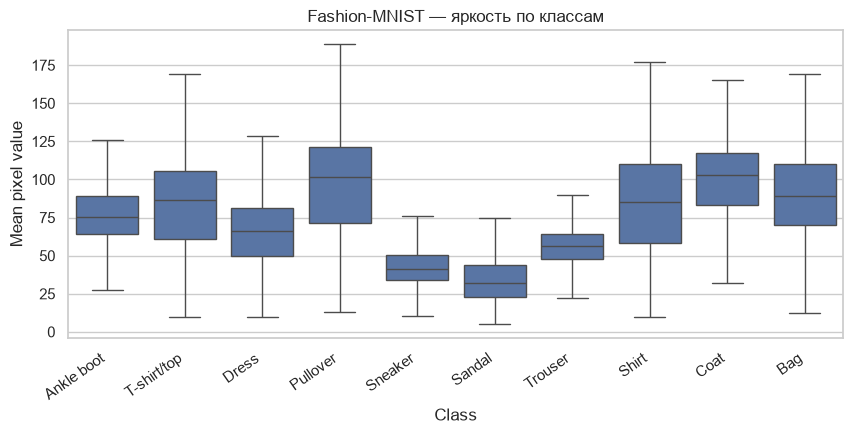

In [15]:
fashion_class_brightness = pd.DataFrame({
    "class": [FASHION_LABELS[label] for label in fashion_targets],
    "brightness": fashion_brightness,
})

plt.figure(figsize=(10, 4))
sns.boxplot(data=fashion_class_brightness, x="class", y="brightness", showfliers=False)
plt.title("Fashion-MNIST — яркость по классам")
plt.xlabel("Class")
plt.ylabel("Mean pixel value")
plt.xticks(rotation=35, ha="right")
plt.savefig(FIGURES_DIR / "eda_fashion_brightness_by_class.png", bbox_inches="tight")
plt.show()


## Где в изображении находится сигнал


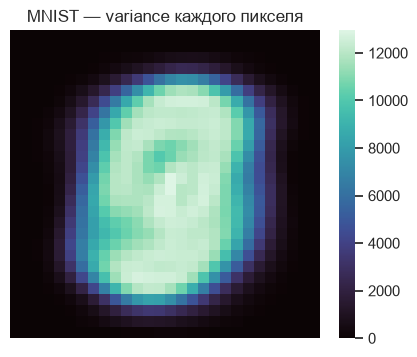

In [16]:
mnist_variance = mnist_images.astype(np.float32).var(axis=0)

plt.figure(figsize=(5, 4))
sns.heatmap(mnist_variance, cmap="mako", cbar=True, xticklabels=False, yticklabels=False)
plt.title("MNIST — variance каждого пикселя")
plt.savefig(FIGURES_DIR / "eda_mnist_pixel_variance.png", bbox_inches="tight")
plt.show()


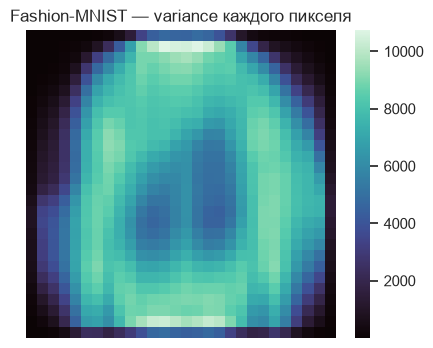

In [17]:
fashion_variance = fashion_images.astype(np.float32).var(axis=0)

plt.figure(figsize=(5, 4))
sns.heatmap(fashion_variance, cmap="mako", cbar=True, xticklabels=False, yticklabels=False)
plt.title("Fashion-MNIST — variance каждого пикселя")
plt.savefig(FIGURES_DIR / "eda_fashion_pixel_variance.png", bbox_inches="tight")
plt.show()


В обоих датасетах информативна в основном центральная область. Но вручную удалять крайние пиксели не буду: это уже отдельное feature engineering и может смешать эффект архитектуры с эффектом представления данных.


## Похожесть классов по их средним изображениям


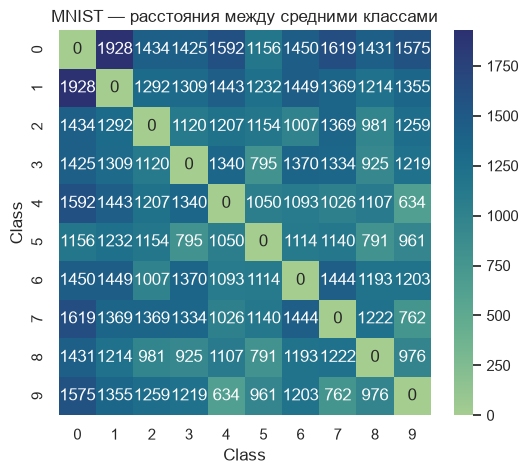

In [18]:
mnist_centroids = np.stack([
    mnist_images[mnist_targets == label].mean(axis=0).ravel()
    for label in range(10)
])

mnist_distances = pairwise_distances(mnist_centroids)

plt.figure(figsize=(6, 5))
sns.heatmap(mnist_distances, annot=True, fmt=".0f", cmap="crest")
plt.title("MNIST — расстояния между средними классами")
plt.xlabel("Class")
plt.ylabel("Class")
plt.savefig(FIGURES_DIR / "eda_mnist_centroid_distances.png", bbox_inches="tight")
plt.show()


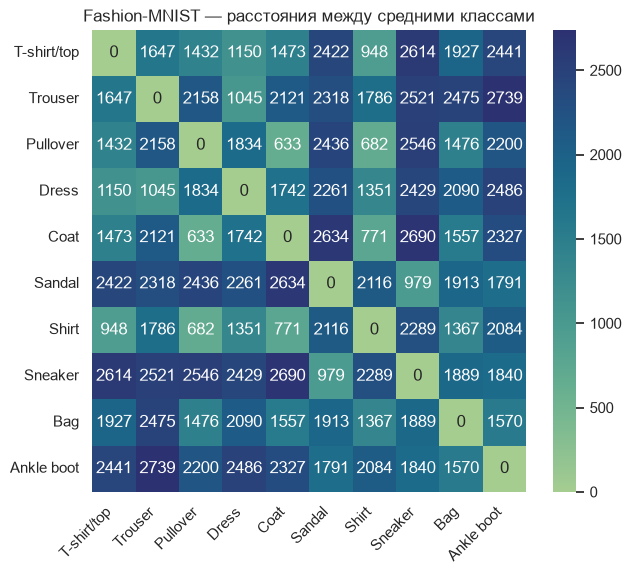

In [19]:
fashion_centroids = np.stack([
    fashion_images[fashion_targets == label].mean(axis=0).ravel()
    for label in range(10)
])

fashion_distances = pairwise_distances(fashion_centroids)

plt.figure(figsize=(7, 6))
sns.heatmap(
    fashion_distances,
    annot=True,
    fmt=".0f",
    cmap="crest",
    xticklabels=FASHION_LABELS,
    yticklabels=FASHION_LABELS,
)
plt.title("Fashion-MNIST — расстояния между средними классами")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.savefig(FIGURES_DIR / "eda_fashion_centroid_distances.png", bbox_inches="tight")
plt.show()


## PCA-проекция


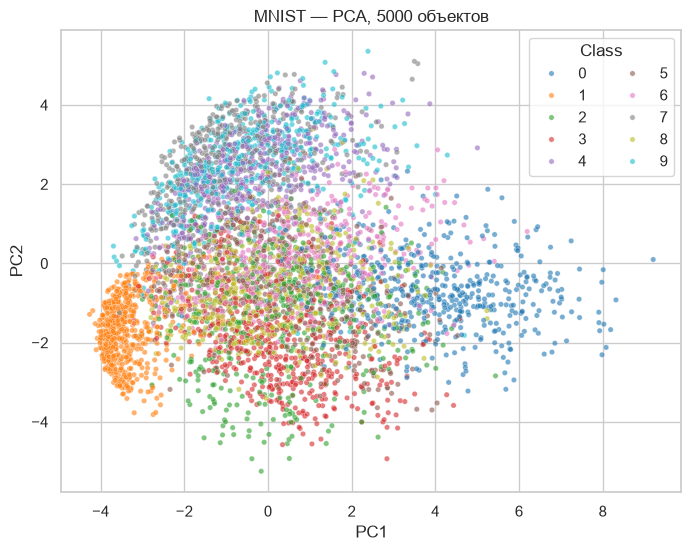

In [20]:
sample_index, _ = train_test_split(
    np.arange(len(mnist_targets)),
    train_size=5000,
    stratify=mnist_targets,
    random_state=SEED,
)

X_sample = mnist_images[sample_index].reshape(len(sample_index), -1) / 255.0
y_sample = mnist_targets[sample_index]

mnist_pca = PCA(n_components=2, random_state=SEED).fit_transform(X_sample)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=mnist_pca[:, 0], y=mnist_pca[:, 1], hue=y_sample, palette="tab10", s=15, alpha=0.6)
plt.title("MNIST — PCA, 5000 объектов")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Class", ncol=2)
plt.savefig(FIGURES_DIR / "eda_mnist_pca.png", bbox_inches="tight")
plt.show()


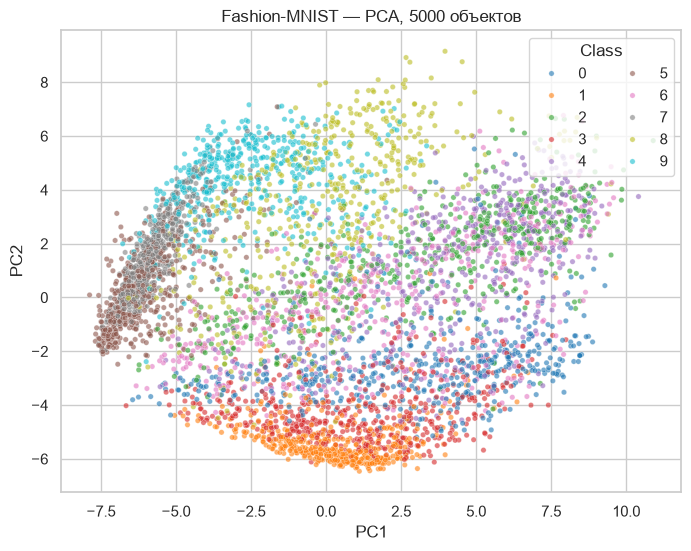

In [21]:
sample_index, _ = train_test_split(
    np.arange(len(fashion_targets)),
    train_size=5000,
    stratify=fashion_targets,
    random_state=SEED,
)

X_sample = fashion_images[sample_index].reshape(len(sample_index), -1) / 255.0
y_sample = fashion_targets[sample_index]

fashion_pca = PCA(n_components=2, random_state=SEED).fit_transform(X_sample)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=fashion_pca[:, 0], y=fashion_pca[:, 1], hue=y_sample, palette="tab10", s=15, alpha=0.6)
plt.title("Fashion-MNIST — PCA, 5000 объектов")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Class", ncol=2)
plt.savefig(FIGURES_DIR / "eda_fashion_pca.png", bbox_inches="tight")
plt.show()


Проекция на первые две компоненты (наибольшая дисперсия) показывает, что в `MNIST` классы сильнее перекрываются, чем в `Fashion-MNIST`.


## Выводы

- `MNIST` и `Fashion-MNIST` имеют одинаковый размер входа и одинаковое число классов — хороший контролируемый набор для исследования архитектуры.
- Сильного дисбаланса нет; сравниваю по `accuracy` и `macro-F1`.
- Пропусков нет, ручное feature engineering не требуется _(во всяком случае, я не придумал, что тут можно сделать... есть вариант попробовать добавить среднюю яркость -- получится выделать отдельный класс, $\textcolor{red}{\#TODO}$)_.
- `Fashion-MNIST` визуально проще; `MNIST` содержит более похожие классы и сильнее перекрывается даже в PCA.
